# 02 — LAMOST MSTO ages vs APOGEE AstroNN ages

Same reference selection (`eos_figures` cuts + `make_masks`, identical chemistry and
kinematic coefficients) applied to **LAMOST subgiants** (Xiang+2024 ages + DD-Payne
[Mg/Fe],[Al/Fe] joined on SPECID), then compared to the APOGEE result from notebook 01.

**Goal:** check whether the precise LAMOST MSTO ages give the same story as the coarse
APOGEE AstroNN ages — in particular the **Eos ≈ Splash (old)** result and the low-α
age–[Fe/H] trend.

LAMOST-specific adaptations (survey, not selection): DD-Payne flags `FLAG_MG_FE==FLAG_AL_FE==0`;
the giant `logg<3.0` cut is a no-op (subgiants, logg~3.8); element-error cut applied to
the fe/mg/al we have; distance from Bailer-Jones `rpgeo`. LAMOST `ENERGY/LZ/VT/R_APO` are
in the same units as AstroNN, so the kinematic selection transfers directly. Median age
error is ~7.5% (vs AstroNN's coarse, >10 Gyr-saturating ages).

## Setup — load both catalogues with the reference code

In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPO = Path('/Users/hanyuan/Library/CloudStorage/Dropbox/python_script/EoS_explore/eos-figures')
sys.path.insert(0, str(REPO))
if not hasattr(np, 'trapz'):
    np.trapz = np.trapezoid

from eos_figures.config import Cuts
from eos_figures.data import load_catalog, make_masks
from eos_figures.stats import bin_percentile, kde_curve, hist2d, stat2d, finite_percentile
from eos_figures.plotting import (setup_axes, smoothed_scatter_panel, label_axes,
                                  density_panel, value_panel)
from eos_figures.figures import _idl_low_density_mask

DATA = Path('/Users/hanyuan/Library/CloudStorage/Dropbox/python_script/EoS_explore/data_repro')
FIGDIR = Path('/Users/hanyuan/Library/CloudStorage/Dropbox/python_script/EoS_explore/figures_repro')
FIGDIR.mkdir(exist_ok=True)
c = Cuts()
AGER = (0.0, 16.5)   # LAMOST MSTO ages extend well past 12 Gyr (tail to ~16); widen so the full distribution shows

apo = load_catalog(DATA / 'our_apogee_dr17_lite_ann.fits.gz')
lam = load_catalog(DATA / 'our_lamost_subgiant_ddpayne.fits.gz')
mA = make_masks(apo, c)
mL = make_masks(lam, c)
print(f'APOGEE rows {len(apo):,}   LAMOST rows {len(lam):,}')

APOGEE rows 529,044   LAMOST rows 198,304


## Population + age-sample sizes, and median ages
Apples-to-apples: same mask names in both surveys.

In [2]:
def summ(cat, m, mk):
    a = cat['age'][m[mk]]; a = a[np.isfinite(a)]
    return int(m[mk].sum()), np.median(a), np.percentile(a,16), np.percentile(a,84)

rows = [('Eos',           'thin_al_vt_rap_age'),
        ('Splash',        'thick_al_splash_age'),
        ('low-alpha disc','thin_al_age')]
print(f'{"population":15s} | {"APOGEE AstroNN (n, med[16-84])":34s} | LAMOST MSTO (n, med[16-84])')
print('-'*95)
for name, mk in rows:
    nA, mdA, lA, hA = summ(apo, mA, mk)
    nL, mdL, lL, hL = summ(lam, mL, mk)
    print(f'{name:15s} | n={nA:6d}  {mdA:4.1f} [{lA:4.1f}-{hA:4.1f}] Gyr        | n={nL:6d}  {mdL:4.1f} [{lL:4.1f}-{hL:4.1f}] Gyr')

population      | APOGEE AstroNN (n, med[16-84])     | LAMOST MSTO (n, med[16-84])
-----------------------------------------------------------------------------------------------
Eos             | n=   172   7.4 [ 6.1- 8.4] Gyr        | n=   137  10.7 [ 6.1-12.1] Gyr
Splash          | n=  3713   8.5 [ 7.1- 9.4] Gyr        | n=  1052  12.2 [10.3-13.3] Gyr
low-alpha disc  | n=107869   4.7 [ 2.4- 6.7] Gyr        | n=144888   6.1 [ 3.4- 9.0] Gyr


## Chemical planes for LAMOST (reference Fig 1) — [Mg/Fe] and [Al/Fe] vs [Fe/H]
Same selection lines as APOGEE: dashed = accreted/in-situ (`-0.30[Fe/H]-0.10`),
dotted = high-α/low-α (`-0.14[Fe/H]+0.135`); horizontal dashed = in-situ Al cut (-0.12).
[Mg/Fe] is DD-Payne Mg (the α proxy). Base sample = LAMOST `make_masks['base']`.

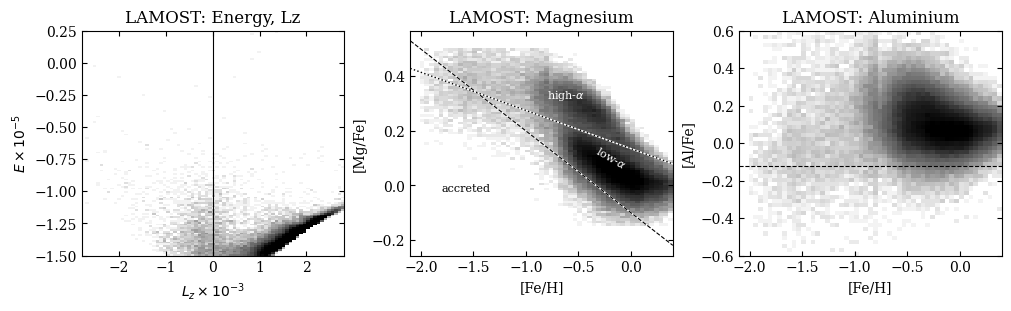

In [3]:
cat, m = lam, mL
fig, ax = setup_axes(3, figsize=(10, 3))

h, xe, ye = hist2d(cat["lz"][m["base"]], 1e-5 * cat["energy"][m["base"]], c.lzr, c.enr, c.nlz, c.nen)
density_panel(ax[0], h, xe * 1e-3, ye, percentiles=(1, 95), vmin=-0.3)
ax[0].axvline(0, color="k", lw=0.8)
label_axes(ax[0], r"$L_z\times 10^{-3}$", r"$E\times 10^{-5}$", "LAMOST: Energy, Lz")

h, xe, ye = hist2d(cat["fe_h"][m["base"]], cat["mg_fe"][m["base"]], c.fehr, c.mgfer, c.nfeh, c.nmg)
density_panel(ax[1], h, xe, ye, percentiles=(2, 98))
xx = np.array(c.fehr)
ax[1].plot(xx, c.slope_acc * xx + c.inter_acc, "w-", lw=1.1)
ax[1].plot(xx, c.slope_acc * xx + c.inter_acc, "k--", lw=0.8)
ax[1].plot(xx, c.slope_acc2 * xx + c.inter_acc2, "w-", lw=1.1)
ax[1].plot(xx, c.slope_acc2 * xx + c.inter_acc2, "k:", lw=1.0)
ax[1].text(-1.8, -0.02, "accreted", fontsize=8)
ax[1].text(-0.8, 0.32, r"high-$\alpha$", color="w", fontsize=8)
ax[1].text(-0.35, 0.06, r"low-$\alpha$", color="w", fontsize=8, rotation=-30)
label_axes(ax[1], "[Fe/H]", "[Mg/Fe]", "LAMOST: Magnesium")

h, xe, ye = hist2d(cat["fe_h"][m["base"]], cat["al_fe"][m["base"]], c.fehr, c.alfer, c.nfeh, c.nal)
density_panel(ax[2], h, xe, ye, percentiles=c.perc1)
ax[2].axhline(c.alfe_cut, color="k", ls="--", lw=0.8)
label_axes(ax[2], "[Fe/H]", "[Al/Fe]", "LAMOST: Aluminium")
fig.savefig(FIGDIR / '02_lamost_chem_mg_al.png', dpi=150, bbox_inches='tight')
plt.show()

## Chemical populations for LAMOST (reference Fig 2) — [Al/Fe] vs [Fe/H]
Top: column-normalised density for accreted / high-α / low-α. Bottom: same bins coloured
by median $V_{\rm tan}$. Dashed lines = the `0.9[Fe/H]+0.9` diagonal and the -0.12 Al cut.
DD-Payne [Al/Fe] is ~3x noisier than APOGEE, so the sequences are broader here.

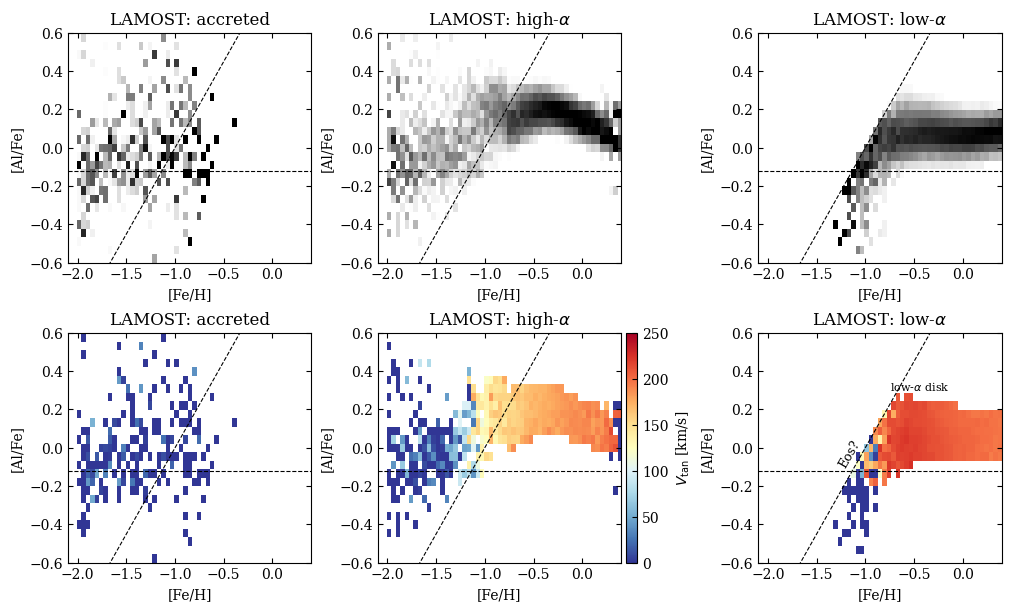

In [4]:
cat, m = lam, mL
fig, ax = setup_axes(3, nrows=2, figsize=(10, 6))
specs = [("acc", "accreted", c.perc),
         ("thick", r"high-$\alpha$", c.perc2),
         ("thin", r"low-$\alpha$", c.perc2)]
hist_cache, mask_cache = {}, {}
for i, (mask_name, title, perc) in enumerate(specs):
    h, xe, ye = hist2d(cat["fe_h"][m[mask_name]], cat["al_fe"][m[mask_name]], c.fehr, c.alfer, c.nfeh, c.nal2, normalize="x")
    hist_cache[mask_name] = (h, xe, ye)
    mask_cache[mask_name] = _idl_low_density_mask(h, perc, c.white_lim)
    density_panel(ax[i], h, xe, ye, percentiles=perc)
    ax[i].plot(c.fehr, np.array(c.fehr) * c.kalfe + c.offalfe, "k--", lw=0.8)
    ax[i].axhline(c.alfe_cut, color="k", ls="--", lw=0.8)
    ax[i].set_xlim(c.fehr); ax[i].set_ylim(c.alfer)
    label_axes(ax[i], "[Fe/H]", "[Al/Fe]", "LAMOST: " + title)

for i, (mask_name, title, _) in enumerate(specs, start=3):
    h, xe, ye = hist_cache[mask_name]
    vmask = (m[mask_name] & np.isfinite(cat["galvt"])
             & (cat["galvt"] >= c.vtanr[0]) & (cat["galvt"] <= c.vtanr[1]))
    med, _, _ = stat2d(cat["fe_h"][vmask], cat["al_fe"][vmask], cat["galvt"][vmask], c.fehr, c.alfer, c.nfeh, c.nal2)
    h_med, _, _ = hist2d(cat["fe_h"][vmask], cat["al_fe"][vmask], c.fehr, c.alfer, c.nfeh, c.nal2)
    med = np.nan_to_num(med, nan=0.0); med[h_med <= 2] = 0.0
    value_panel(ax[i], med, xe, ye, *c.mm_vtan, mask=mask_cache[mask_name],
                cmap="RdYlBu_r", colorbar_label=r"$V_{\rm tan}$ [km/s]" if i == 4 else None)
    ax[i].plot(c.fehr, np.array(c.fehr) * c.kalfe + c.offalfe, "k--", lw=0.8)
    ax[i].axhline(c.alfe_cut, color="k", ls="--", lw=0.8)
    ax[i].set_xlim(c.fehr); ax[i].set_ylim(c.alfer)
    label_axes(ax[i], "[Fe/H]", "[Al/Fe]", "LAMOST: " + title)
ax[5].text(-1.3, -0.1, "Eos?", fontsize=9, rotation=60)
ax[5].text(-0.75, 0.3, r"low-$\alpha$ disk", fontsize=8)
fig.savefig(FIGDIR / '02_lamost_alfe_pops.png', dpi=150, bbox_inches='tight')
plt.show()

## [Fe/H] vs $V_{\rm tan}$ for high-α and low-α — APOGEE vs LAMOST
Rows: APOGEE (top), LAMOST (bottom). Columns: high-α (`thick_al`), low-α (`thin_al`).
Dashed line = $V_{\rm tan}=0$. The high-α panels show the Splash (low-$V_{\rm tan}$ at the
metal-poor end); the low-α panels show the rotating disc with the **Eos tail** dropping
toward $V_{\rm tan}\approx0$ at [Fe/H]≈−1.

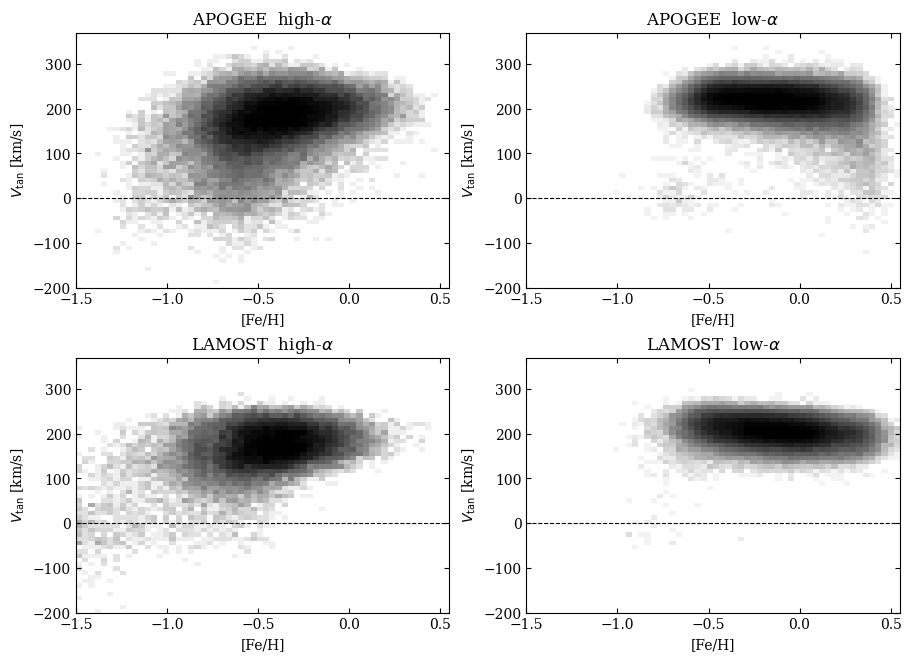

In [5]:
FEHR, VTR = c.fehr_plot, c.vphir_plot2
fig, ax = setup_axes(2, nrows=2, figsize=(9, 6.5))
panels = [(apo, mA, "thick_al", r"APOGEE  high-$\alpha$"),
          (apo, mA, "thin_al",  r"APOGEE  low-$\alpha$"),
          (lam, mL, "thick_al", r"LAMOST  high-$\alpha$"),
          (lam, mL, "thin_al",  r"LAMOST  low-$\alpha$")]
for axis, (cat, m, mk, title) in zip(ax, panels):
    h, xe, ye = hist2d(cat["fe_h"][m[mk]], cat["galvt"][m[mk]], FEHR, VTR, 60, 60)
    density_panel(axis, h, xe, ye, percentiles=(2, 98))
    axis.axhline(0, color="k", ls="--", lw=0.8)
    axis.set_xlim(FEHR); axis.set_ylim(VTR)
    axis.set_xticks([-1.5, -1.0, -0.5, 0.0, 0.5])
    label_axes(axis, "[Fe/H]", r"$V_{\rm tan}$ [km/s]", title)
fig.savefig(FIGDIR / '02_feh_vtan_pops.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure — LAMOST's own age panels (Fig 6 reproduced with MSTO ages)
Left: age–[Fe/H] tracks (low-α vs high-α). Middle: low-α, $V_{\rm tan}<80$, coloured by $r_{\rm apo}$.
Right: age distributions of Eos, Splash, low-α disc — the internal Eos≈Splash check.

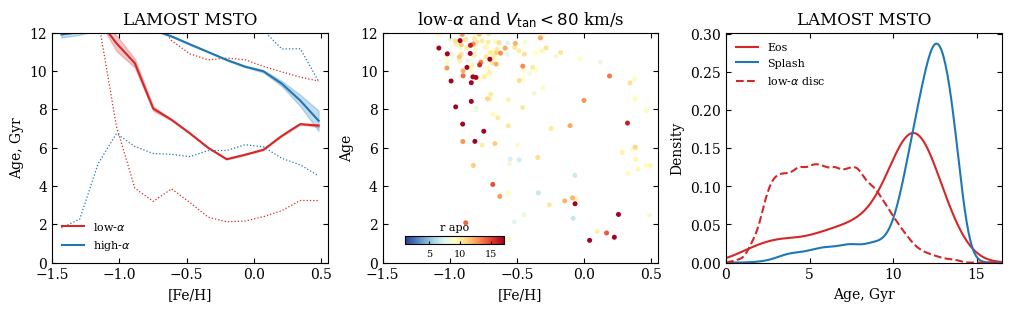

In [6]:
cat, m = lam, mL
fig, ax = setup_axes(3, figsize=(10, 3))
for mask_name, color, label in [("thin_al_age", "tab:red", r"low-$\alpha$"), ("thick_age", "tab:blue", r"high-$\alpha$")]:
    xcen, _, med, std, n = bin_percentile(cat["fe_h"][m[mask_name]], cat["age"][m[mask_name]], c.fehr_plot, c.nbins_age, 50)
    _, _, p5, _, _  = bin_percentile(cat["fe_h"][m[mask_name]], cat["age"][m[mask_name]], c.fehr_plot, c.nbins_age, 5)
    _, _, p95, _, _ = bin_percentile(cat["fe_h"][m[mask_name]], cat["age"][m[mask_name]], c.fehr_plot, c.nbins_age, 95)
    err = np.divide(std, np.sqrt(n), out=np.full_like(std, np.nan), where=n > 0)
    good = np.isfinite(med)
    ax[0].fill_between(xcen[good], med[good]-err[good], med[good]+err[good], color=color, alpha=0.25)
    ax[0].plot(xcen, med, color=color, label=label)
    ax[0].plot(xcen, p5, color=color, ls=":", lw=0.9); ax[0].plot(xcen, p95, color=color, ls=":", lw=0.9)
ax[0].set_xlim(c.fehr_plot); ax[0].set_ylim(c.ager); ax[0].legend(frameon=False, fontsize=8)
label_axes(ax[0], "[Fe/H]", "Age, Gyr", "LAMOST MSTO")

sc = smoothed_scatter_panel(ax[1], cat["fe_h"][m["thin_al_vt_age"]], cat["age"][m["thin_al_vt_age"]],
                            cat["rap"][m["thin_al_vt_age"]], c.fehr_plot, c.ager, cmap="RdYlBu_r",
                            vmin=c.mm_rapo[0], vmax=c.mm_rapo[1], s=13)
ax[1].set_xlim(c.fehr_plot); ax[1].set_ylim(c.ager)
cax = ax[1].inset_axes([0.08, 0.08, 0.36, 0.035])
cb = fig.colorbar(sc, cax=cax, orientation="horizontal"); cb.set_label("r apo", fontsize=8)
cb.ax.xaxis.set_label_position("top"); cb.ax.xaxis.set_ticks_position("bottom"); cb.ax.tick_params(labelsize=7, length=2)
label_axes(ax[1], "[Fe/H]", "Age", r"low-$\alpha$ and $V_{\rm tan}<80$ km/s")

for mask_name, color, label, ls in [("thin_al_vt_rap_age", "tab:red", "Eos", "-"),
                                    ("thick_al_splash_age", "tab:blue", "Splash", "-"),
                                    ("thin_al_age", "tab:red", r"low-$\alpha$ disc", "--")]:
    x, y = kde_curve(cat["age"][m[mask_name]], AGER)
    ax[2].plot(x, y, color=color, ls=ls, label=label)
ax[2].set_xlim(AGER); ax[2].set_ylim(0, None); ax[2].legend(frameon=False, fontsize=8)
label_axes(ax[2], "Age, Gyr", "Density", "LAMOST MSTO")
fig.savefig(FIGDIR / '02_fig6_age_lamost.png', dpi=150, bbox_inches='tight')
plt.show()

## KEY comparison — age distributions, APOGEE AstroNN vs LAMOST MSTO
Same population in each panel; blue = APOGEE AstroNN, red = LAMOST MSTO. Vertical lines
mark the medians. Consistency = the two surveys agree on the ordering (Eos old ≈ Splash,
low-α disc younger), even though AstroNN ages saturate/compress above ~10 Gyr.

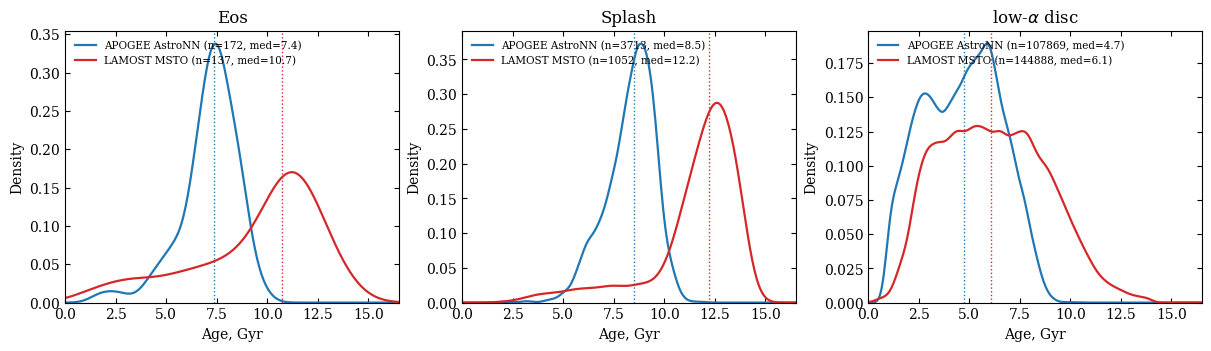

In [7]:
fig, ax = setup_axes(3, figsize=(12, 3.4))
pairs = [("thin_al_vt_rap_age", "Eos"), ("thick_al_splash_age", "Splash"), ("thin_al_age", r"low-$\alpha$ disc")]
for axis, (mk, title) in zip(ax, pairs):
    for cat, m, color, lab in [(apo, mA, "tab:blue", "APOGEE AstroNN"), (lam, mL, "tab:red", "LAMOST MSTO")]:
        a = cat["age"][m[mk]]; a = a[np.isfinite(a)]
        x, y = kde_curve(a, AGER)
        axis.plot(x, y, color=color, lw=1.6, label=f"{lab} (n={a.size}, med={np.median(a):.1f})")
        axis.axvline(np.median(a), color=color, ls=":", lw=1.0)
    axis.set_xlim(AGER); axis.set_ylim(0, None)
    axis.legend(frameon=False, fontsize=7.5, loc="upper left")
    label_axes(axis, "Age, Gyr", "Density", title)
fig.savefig(FIGDIR / '02_compare_agedist.png', dpi=150, bbox_inches='tight')
plt.show()

## Comparison — age–[Fe/H] tracks, APOGEE vs LAMOST
Median age vs [Fe/H] with standard-error bands. If the surveys agree, the low-α (red)
and high-α (blue) tracks overlap in shape; LAMOST should show the same low-α upturn to
old ages at the metal-poor (Eos) end that motivates the Eos≈Splash comparison.

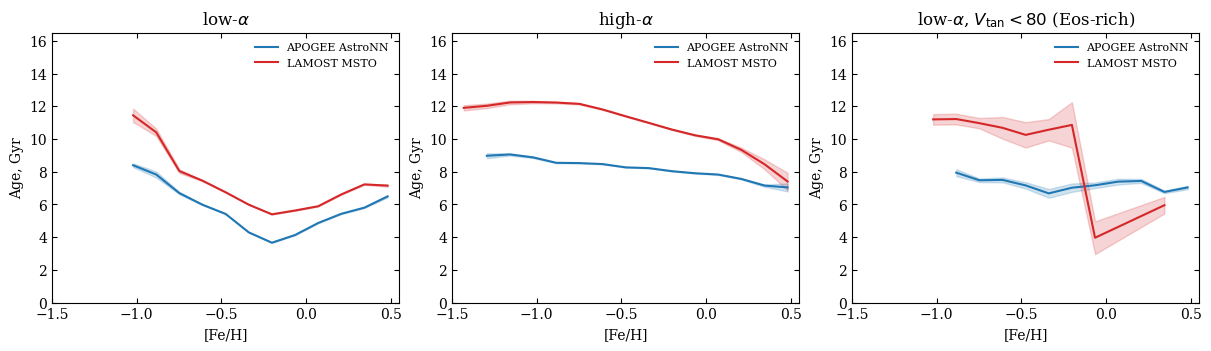

In [8]:
fig, ax = setup_axes(3, figsize=(12, 3.4))
def track(axis, cat, m, mk, color, ls, label):
    xcen, _, med, std, n = bin_percentile(cat["fe_h"][m[mk]], cat["age"][m[mk]], c.fehr_plot, c.nbins_age, 50)
    err = np.divide(std, np.sqrt(n), out=np.full_like(std, np.nan), where=n > 0)
    good = np.isfinite(med) & (n > 5)
    axis.fill_between(xcen[good], med[good]-err[good], med[good]+err[good], color=color, alpha=0.20)
    axis.plot(xcen[good], med[good], color=color, ls=ls, label=label)

# low-alpha disc
track(ax[0], apo, mA, "thin_al_age", "tab:blue", "-", "APOGEE AstroNN")
track(ax[0], lam, mL, "thin_al_age", "tab:red", "-", "LAMOST MSTO")
ax[0].set_title(r"low-$\alpha$"); ax[0].legend(frameon=False, fontsize=8)
# high-alpha
track(ax[1], apo, mA, "thick_age", "tab:blue", "-", "APOGEE AstroNN")
track(ax[1], lam, mL, "thick_age", "tab:red", "-", "LAMOST MSTO")
ax[1].set_title(r"high-$\alpha$"); ax[1].legend(frameon=False, fontsize=8)
# low-alpha, Vtan<80 (Eos-enriched) tracks
track(ax[2], apo, mA, "thin_al_vt_age", "tab:blue", "-", "APOGEE AstroNN")
track(ax[2], lam, mL, "thin_al_vt_age", "tab:red", "-", "LAMOST MSTO")
ax[2].set_title(r"low-$\alpha$, $V_{\rm tan}<80$ (Eos-rich)"); ax[2].legend(frameon=False, fontsize=8)
for axis in ax:
    axis.set_xlim(c.fehr_plot); axis.set_ylim(AGER)
    label_axes(axis, "[Fe/H]", "Age, Gyr")
fig.savefig(FIGDIR / '02_compare_agefeh.png', dpi=150, bbox_inches='tight')
plt.show()